<a href="https://colab.research.google.com/github/rishabkundu2003/ARTIFICIAL-INTELLIGENCE/blob/main/ANN(AI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
class MP_OR:
    def __init__(self):
        self.theta=1
    def predict(self,x1,x2):
        g=x1+x2
        if g>=self.theta:
            return 1
        else:
            return 0


In [2]:
orfun=MP_OR()
print(orfun.predict(1,1))


1


In [3]:
orfun=MP_OR()
print(orfun.predict(0,0))

0


In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
#import cv2
import matplotlib.pyplot as plt

In [5]:
fashion=keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test)=fashion.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_train.shape

(60000, 28, 28)

In [7]:
y_train.shape

(60000,)

In [8]:
x_test.shape

(10000, 28, 28)

In [9]:
x_train,x_val=x_train[:10000]/255.0,x_train[10000:]/255.0
y_train,y_val=y_train[:10000],y_train[10000:]

In [10]:
y_train[3]

np.uint8(3)

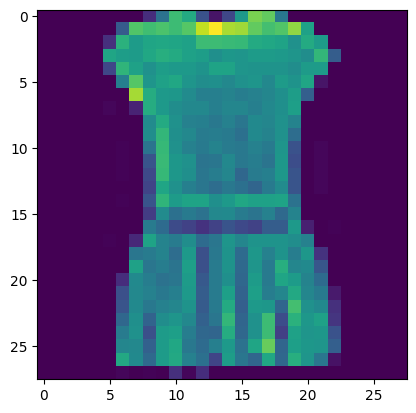

In [11]:
plt.imshow(x_train[3])

In [12]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [13]:
class_names[y_train[3]]

'Dress'

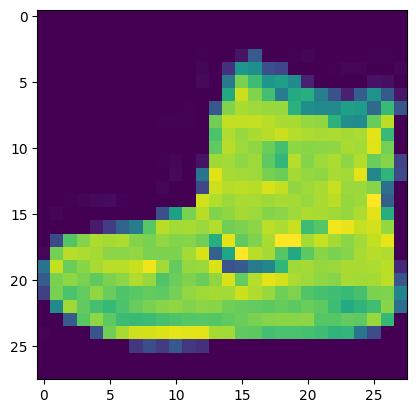

In [14]:
plt.imshow(x_train[0])

Dress


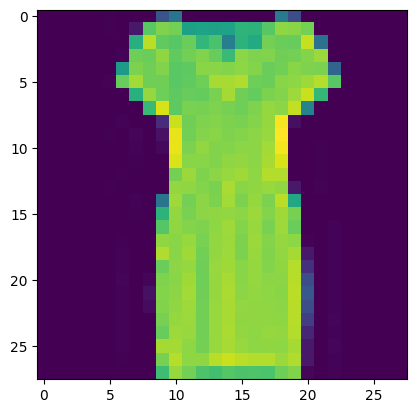

In [15]:
print(class_names[y_train[20]])
plt.imshow(x_train[20])

In [16]:
model=keras.models.Sequential()

In [17]:
model.add(keras.layers.Flatten(input_shape=[28,28]))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model.add(keras.layers.Dense(300, activation="relu"))

In [19]:
model.add(keras.layers.Dense(100, activation="relu"))

In [20]:
model.add(keras.layers.Dense(10,activation='softmax'))

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.layers

[<Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

In [23]:
model.layers[0]

<Flatten name=flatten, built=True>

In [24]:
model.layers[1].name

'dense'

In [25]:
weights,bias=model.layers[1].get_weights()

In [26]:
weights.shape

(784, 300)

In [27]:
bias.shape

(300,)

In [28]:
weights,bias=model.layers[2].get_weights()

In [29]:
bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [30]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

In [31]:
history = model.fit(x_train, y_train, epochs=30,validation_data=(x_val, y_val))

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6157 - loss: 1.2391 - val_accuracy: 0.7000 - val_loss: 0.8594
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7556 - loss: 0.7329 - val_accuracy: 0.7832 - val_loss: 0.6677
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7918 - loss: 0.6253 - val_accuracy: 0.7955 - val_loss: 0.6007
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8079 - loss: 0.5706 - val_accuracy: 0.7982 - val_loss: 0.5846
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8195 - loss: 0.5301 - val_accuracy: 0.7987 - val_loss: 0.5632
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8295 - loss: 0.5070 - val_accuracy: 0.7634 - val_loss: 0.6517
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8342 - loss: 0.4872 - val_accuracy: 0.8319 - val_loss: 0.4967
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8399 - loss: 0.4686 - val_accu

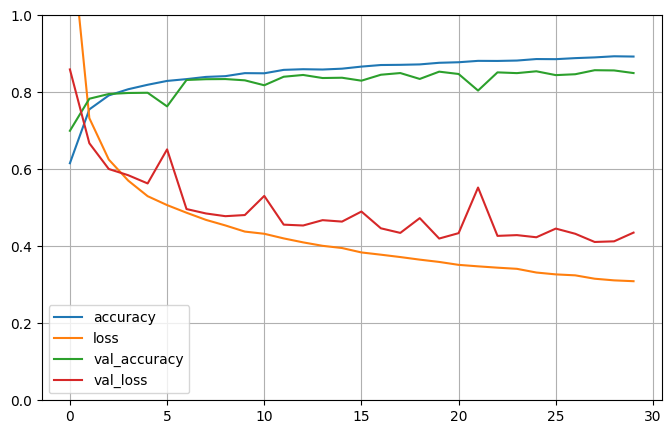

In [32]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [33]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7946 - loss: 103.0050


[103.00498962402344, 0.7946000099182129]

In [34]:
X_new = x_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

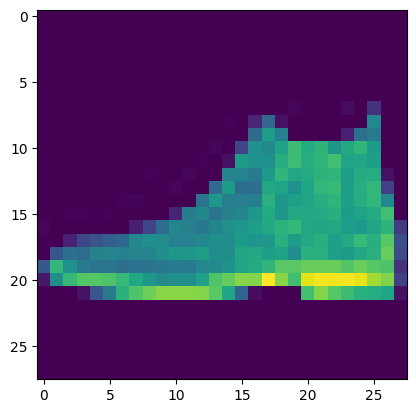

In [35]:
plt.imshow(x_test[0])

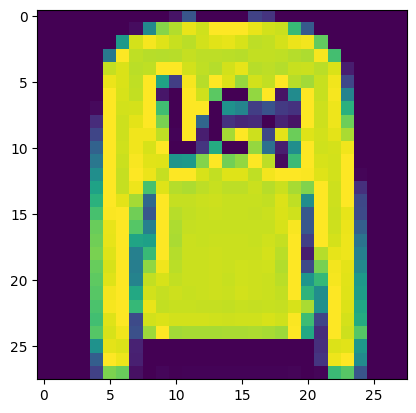

In [36]:
plt.imshow(x_test[1])

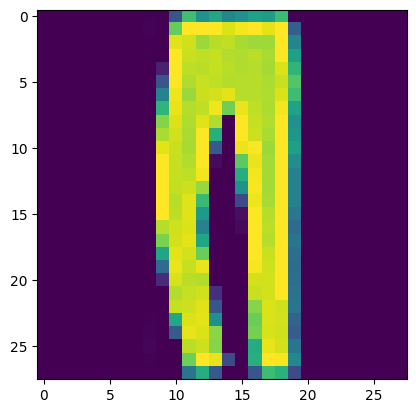

In [37]:
plt.imshow(x_test[2])

In [38]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [39]:
housing = fetch_california_housing()

In [40]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [42]:
X_train.shape[1:]


(8,)

In [43]:
model = keras.models.Sequential([
keras.layers.Dense(30, activation="sigmoid", input_shape=X_train_scaled.shape[1:]),
keras.layers.Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
